# Notebook 02: Data Exploration and Analysis
**Goal:** to use PCA and SVD to figure out stability and the biological significance of created principal components

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, TruncatedSVD

# Loading cleaned data from notebook 01
X = pd.read_csv('X_train_cleaned.csv', index_col=0)
y = np.load('y_train.npy')

# Loading top 50 genes from before
import json
with open('top_50_genes.json', 'r') as f:
    top_50_genes = json.load(f)
with open('top_100_genes.json', 'r') as f1:
    top_100_genes = json.load(f1)
with open('top_5_genes.json', 'r') as f2:
    top_5_genes = json.load(f2)

X_50 = X[top_50_genes]
X_100 = X[top_100_genes]
X_5 = X[top_5_genes]


Implementing PCA and SVD for reducing dimensionality and figuring out key biomarkers

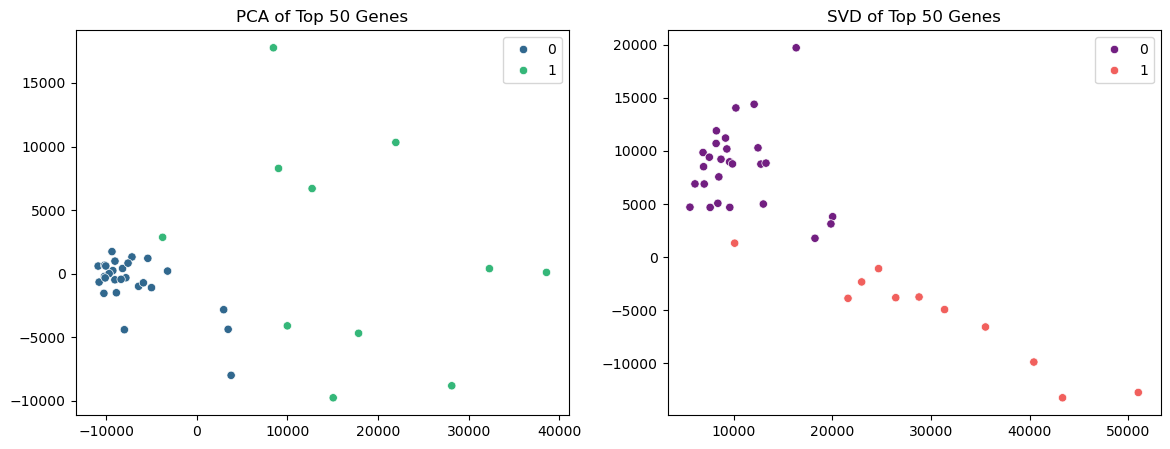

In [65]:
# PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_50)

# SVD
svd = TruncatedSVD(n_components = 2)
X_svd = svd.fit_transform(X_50)

# Plotting the comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, ax=ax[0], palette='viridis')
ax[0].set_title('PCA of Top 50 Genes')

sns.scatterplot(x=X_svd[:, 0], y=X_svd[:, 1], hue=y, ax=ax[1], palette='magma')
ax[1].set_title('SVD of Top 50 Genes')

plt.show()

**Observation:**

 ALL (0) shows tight clustering, however AML (1) is scattered (high variance) across the plot and has a smaller sample size (11). This suggests that the top 50 genes are more consistent markers for ALL than AML and biologically this could mean that AML shows a more heterogenous transcriptomic profile, where some genes may be high noise and high signal. PC1 appears to be the primary axis of class separation.

**Failure mode analysis:**

Scattering of 1s (AML) can be attributed to:

*Sub-types:* AML having different mutations may cause some patients to showcase more gene similarity to ALL patients than others.

*Low sample size:* only 11 patients having AML leaves the data susceptible to outliers where 1 patient with a very different profile (immune response or genetic) may skew the entirety of the data.

### Ablation 01: 

**Hypothesis:** Does increasing gene selection count separate ALL vs AML more accurately due to the inclusion of more biomarkers?

**Method:** PCA and SVD, same as before but for the top 100 genes instead

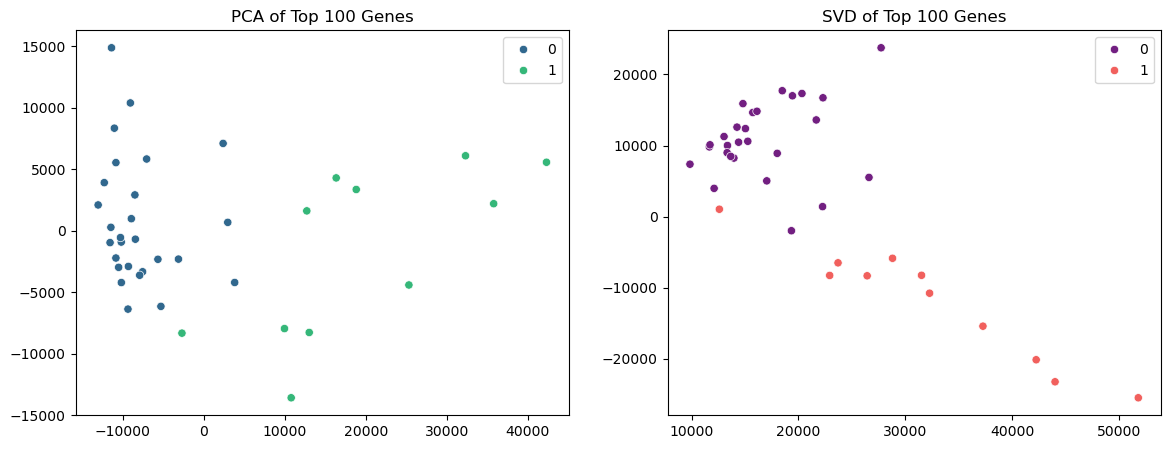

In [66]:
# PCA for 100
pca1 = PCA(n_components = 2)
X_pca1 = pca1.fit_transform(X_100)

# SVD for 100
svd1 = TruncatedSVD(n_components = 2)
X_svd1 = svd1.fit_transform(X_100)

# Plotting the comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca1[:, 0], y=X_pca1[:, 1], hue=y, ax=ax[0], palette='viridis')
ax[0].set_title('PCA of Top 100 Genes')

sns.scatterplot(x=X_svd1[:, 0], y=X_svd1[:, 1], hue=y, ax=ax[1], palette='magma')
ax[1].set_title('SVD of Top 100 Genes')

plt.show()

In [67]:
# Finding the top 10 marker genes (PC1) and figuring out their biological significance
loadings = pd.DataFrame(
    pca.components_.T,
    columns = ['PC1', 'PC2'],
    index = top_50_genes
)

print("---Top 10 Biological PC1 and PC2 drivers---") 
print(loadings['PC1'].abs().sort_values(ascending = False).head(10))
print (" ")
print(loadings['PC2'].abs().sort_values(ascending = False).head(10))

---Top 10 Biological PC1 and PC2 drivers---
Y00787_s_at         0.416506
M11147_at           0.400947
M69043_at           0.343013
M27891_at           0.292104
M28130_rna1_s_at    0.261267
M19045_f_at         0.251352
X14008_rna1_f_at    0.248430
X17042_at           0.210507
M96326_rna1_at      0.200154
M63138_at           0.151244
Name: PC1, dtype: float64
 
M96326_rna1_at      0.627610
Y00787_s_at         0.385776
M84526_at           0.277682
M27891_at           0.277159
M11147_at           0.255907
M28130_rna1_s_at    0.255037
M69043_at           0.198856
X17042_at           0.179379
X04085_rna1_at      0.171255
M63138_at           0.092585
Name: PC2, dtype: float64


**Loading Result:**

PC1 indexes on *Y00787_s_at (Interleukin-8 / IL8)*: a pro-inflammatory cytokine that helps build blood vessels leading into the cancer cell, helping it move and survive, and *M11147_at (Ferritin Light Chain)*: which relates to how the cell stores iron; AML is notorious for messing with iron metabolism to fuel their growth.

PC2 indexes on *M96326_rna1_at (Azurocidin)*, and this is an interesting find since it pertains almost exclusively to AML and can explain the y axis spread of the data and the heterogenous transcriptomic profile of AML mentioned earlier.



### Ablation 02: 

**Hypothesis:** Does only including the top 5 marker genes from SNR provide better separation and clarity due to reduced "noise" and increased differentiation? And does PCA help us figure out a co-relationship between the top genes from SNR?

**Theory:** SNR looks for "IDs" (sort of like a security guard) and only cares about the difference in presence of certain genes between ALL and AML whereas PCA cares about the genes that provide the most variance in the spread (like a photographer who cares about the most interesting movements).

SNR looks at the genes in a vacuum and only checks to see their presence or absence in our defined classes, PCA can then be used on this data to figure out if there is any relationship between the genes here allowing them to be "bundled" together with high weights.

SNR is *Supervised*: It needs the "Answer Key" (y_train) to calculate the difference between the groups. It finds the Separators.

PCA is *Unsupervised*: It ignores the "Answer Key." It just finds the genes that vary the most across everyone. It finds the Drivers.

**Method:** PCA and SVD, same as before but for the top 5 genes instead.

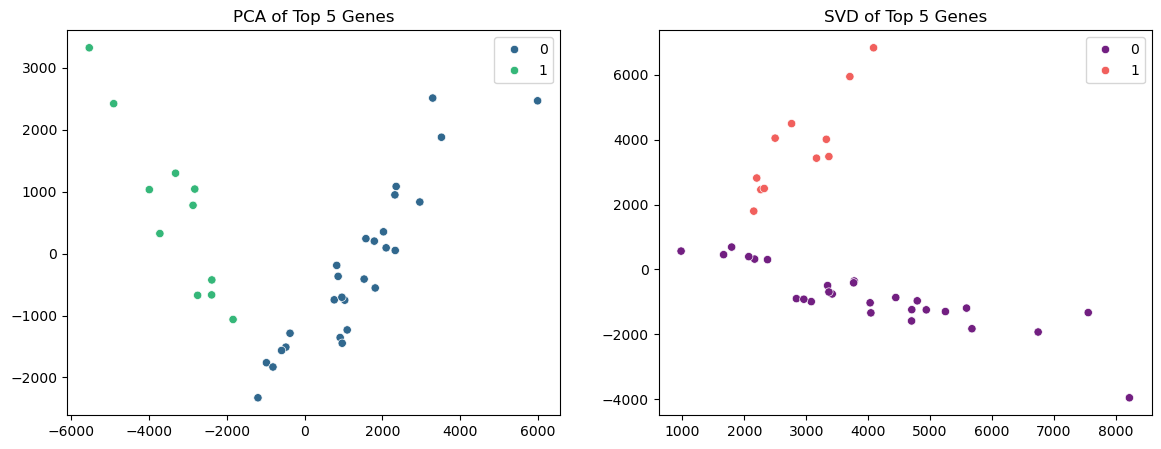

In [68]:
# PCA for 5
pca2 = PCA(n_components = 2)
X_pca2 = pca2.fit_transform(X_5)

# SVD for 100
svd2 = TruncatedSVD(n_components = 2)
X_svd2 = svd2.fit_transform(X_5)

# Plotting the comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_pca2[:, 0], y=X_pca2[:, 1], hue=y, ax=ax[0], palette='viridis')
ax[0].set_title('PCA of Top 5 Genes')

sns.scatterplot(x=X_svd2[:, 0], y=X_svd2[:, 1], hue=y, ax=ax[1], palette='magma')
ax[1].set_title('SVD of Top 5 Genes')

plt.show()

**Result:**

*top_100:* Scattered

*top_5:* Flipped arrow shape

**Observations:**

**top_100:** "More is Less" seems to hold true here since the points are more scattered than they were in the top_50 version, indicating that genes 51-100 are likely biological noise and dont contribute significantly to increased accuracy.

**top_5:** Sparsity due to only 5 genes available showcases a downward arrow with flipped axes relative to the top_50, maintaining strong class separation between ALL and AML with high sparsity.

In [69]:
loadings = pd.DataFrame(
    pca2.components_.T,
    columns = ['PC1', 'PC2'],
    index = top_5_genes
)

print("---Top Biological PC1 and PC2 weights---") 
print(loadings['PC1'].abs().sort_values(ascending = False).head(10))
print (" ")
print(loadings['PC2'].abs().sort_values(ascending = False).head(10))

---Top Biological PC1 and PC2 weights---
U22376_cds2_s_at    0.799363
X95735_at           0.454966
U50136_rna1_at      0.262517
M16038_at           0.240120
M55150_at           0.165688
Name: PC1, dtype: float64
 
X95735_at           0.654298
U22376_cds2_s_at    0.596864
M16038_at           0.341722
U50136_rna1_at      0.277001
M55150_at           0.148811
Name: PC2, dtype: float64


**Loading Result:**

Ablation done on the top 5 genes reveals that the two genes MYL-6(U22376_cds2_s_at) and Zyxin(X95735_at) are the primary weights on both PC1 and PC2 due to their high-loading hence explaining the geometric arrow shape due to their diagonal-like pull on both axes. 

### Conclusion:

**Optimal feature count:** the algorithms show that the top 50 genes selection provides the most accurate class separation whereas the top 100 introduces *noise*.

**Arrow shape:** in the sparse mode (top 5 genes) we can see that the primary weights were *structure related* (MYL-6 and Zyxin). This shows that the structural cell-identity genes are the best separators.

**AML heterogeneity:** ALL clusters with few outliers whereas AML shows high variance, this shows us that AML has a more diverse heterogenous transcriptomic profile than that of ALL.

In [72]:
from datetime import datetime

new_entry = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M"),
    'experiment_id': 'PCA/SVD feature visulaisations',
    'data_version': 'top_5_snr, top_50_snr, top_100_snr',
    'model_type': 'N/A (EDA)',
    'accuracy': 'N/A',
    'f1_score': 'N/A', 
    'notes': "Top 50 genes show the best separation whereas the top 5 show that structural gene cell-identifiers are the main drivers. AML shows more variance than ALL."
}

log_df = pd.read_csv('experiment_log.csv')
log_df = pd.concat([log_df, pd.DataFrame([new_entry])], ignore_index=True)
log_df.to_csv('experiment_log.csv', index=False)